# Part II - Ford GoBike Usage Patterns Presentation
## by José Luis Lázaro Contreras

## Investigation Overview


> The goal of this presentation is to **communicate the most important insights** discovered during the exploratory analysis of the Ford GoBike bike-sharing dataset. Rather than exploring all possible relationships, this presentation focuses on a **small set of key findings** that explain how the system is used and how usage varies across different user groups.


### Executive Summary

> The analysis reveals that:
> - Most bike trips are short, indicating the system is mainly used for brief, practical journeys.
> - **User type** (Subscriber vs Customer) is the strongest factor explaining differences in trip duration.
> - Temporal patterns show peak usage during commuting hours, but trip duration itself remains fairly consistent throughout the day.

> These insights are supported by a concise set of polished visualizations intended for a general audience.



## Dataset Overview and Executive Summary


> The dataset used in this analysis contains **183,412 bike-sharing trips** recorded by the Ford GoBike system in **February 2019**. Each record represents a single trip and includes information about trip duration, start and end times, station locations, and user characteristics.

### Key Insights

> - Trip duration is highly right-skewed, with most trips lasting only a few minutes.
> - Subscribers account for the majority of trips and tend to make shorter, more consistent rides.
> - Customers take longer trips on average and show greater variability in ride duration.
>- Bike usage peaks during typical commuting hours, highlighting the system’s role in daily transportation.


In [1]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# suppress warnings from final output
import warnings
warnings.simplefilter("ignore")

In [2]:
# Load the dataset
df_bikes = pd.read_csv('201902-fordgobike-tripdata.csv', sep=';')

# Feature engineering
df_bikes['start_time'] = pd.to_datetime(df_bikes['start_time'])
df_bikes['start_hour'] = df_bikes['start_time'].dt.hour


## Visualization 1 — Trip Duration Distribution
## Comment

> This visualization shows that most trips are **short in duration**, with a strong concentration of rides lasting only a few minutes. Extremely long trips exist but are relatively rare, which supports the conclusion that the system is primarily used for short-distance travel rather than long recreational rides.

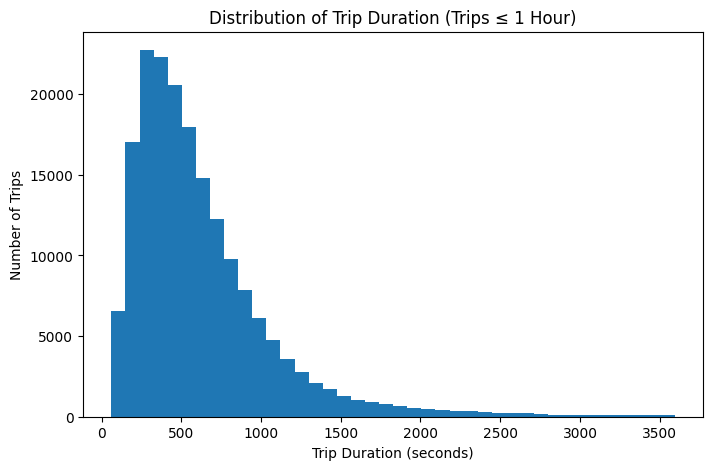

In [3]:
## Graphic 1 Polished histogram
plt.figure(figsize=(8, 5))
plt.hist(df_bikes[df_bikes['duration_sec'] <= 3600]['duration_sec'], bins=40)
plt.title('Distribution of Trip Duration (Trips ≤ 1 Hour)')
plt.xlabel('Trip Duration (seconds)')
plt.ylabel('Number of Trips')
plt.show()

## Visualization 2 — Trip Duration by User Type
## Comment

> This plot highlights a clear behavioral difference between user types. **Customers** tend to take longer and more variable trips compared to **Subscribers**, who typically use the system for short and consistent rides. This suggests different usage motivations, such as leisure versus commuting.

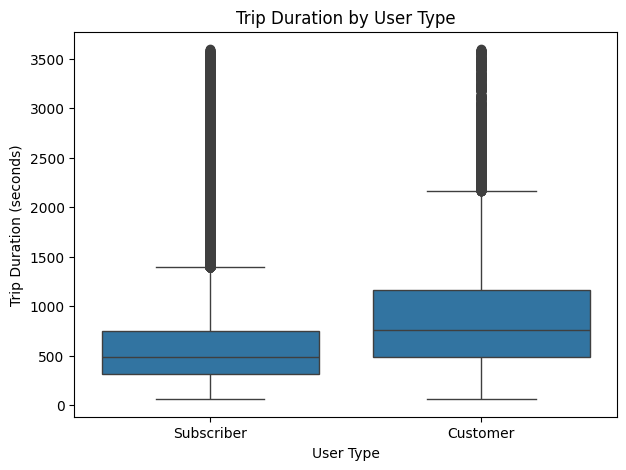

In [4]:
#Graphic 2 Box plot
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df_bikes[df_bikes['duration_sec'] <= 3600],
    x='user_type',
    y='duration_sec'
)
plt.title('Trip Duration by User Type')
plt.xlabel('User Type')
plt.ylabel('Trip Duration (seconds)')
plt.show()

## Visualization 3 — Usage by Hour of Day and User Type
## Comment

> This visualization shows that both Subscribers and Customers use the system throughout the day, with higher activity during commuting hours. While time of day influences **when** trips occur, **user type** better explains differences in **how long** trips last.

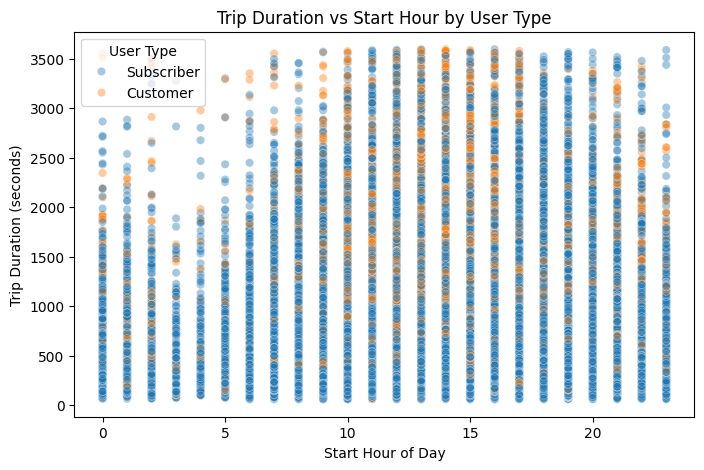

In [5]:
## Chart 3 (Scatter with multiple coding)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_bikes[df_bikes['duration_sec'] <= 3600],
    x='start_hour',
    y='duration_sec',
    hue='user_type',
    alpha=0.4
)
plt.title('Trip Duration vs Start Hour by User Type')
plt.xlabel('Start Hour of Day')
plt.ylabel('Trip Duration (seconds)')
plt.legend(title='User Type')
plt.show()